# Airborne transmission - COVID-19

**Case study: COVID-19 first wave (spring 2020).** An airborne, respiratory pathogen with a latent period and substantial asymptomatic transmission. This is the case where every intervention in the project is on the table, so we use it to show how *lockdown, vaccination* and *quarantine* each enter an epidemic model in a structurally different way: a time-varying contact rate (SIRD + lockdown), an extra compartment (SIRDV), and added latent/asymptomatic/isolation structure (SEAIQR).

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "simulation").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulation import compartmental as cm
from simulation import grid, plotting, metrics
from simulation import interventions as itv
from simulation.grid import ABMParams, InterventionSettings, RandomWalkModel, run_ensemble
from simulation.agents import State

plotting.use_house_style()

## The reported first wave

peak day: 41 | total: 67997


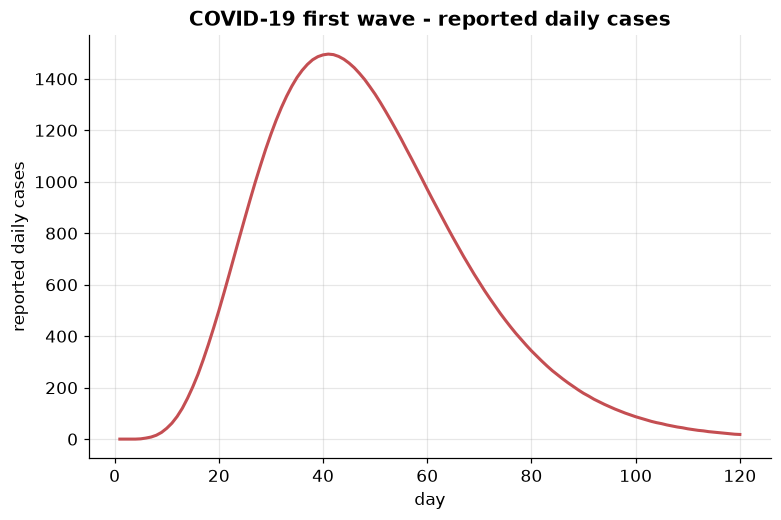

In [2]:
DATA = pathlib.Path.cwd() / "data" / "covid_firstwave_daily.csv"
reported = pd.read_csv(DATA, comment="#")

fig, ax = plt.subplots()
ax.plot(reported["day"], reported["cases"], color=plotting.PALETTE["I"], lw=2)
ax.set_xlabel("day"); ax.set_ylabel("reported daily cases")
ax.set_title("COVID-19 first wave - reported daily cases")
print("peak day:", int(reported.loc[reported['cases'].idxmax(), 'day']),
      "| total:", int(reported['cases'].sum()))

## Baseline - SIRD with fatalities

Natural-history rates are from the COVID literature [5]; R0 = 2.7 is a representative first-wave value.

In [ ]:
# Population and natural-history parameters for the first wave.

N   = 1_000_000
I0  = 100
gamma = 1 / 6.0            # 6 day infectious period
sigma = 1 / 5.1           # incubation rate, 5.1 day latent period [5]
DAYS  = 220

cfr = 0.007               # infection fatality ratio 0.7%
mu  = cfr * gamma / (1 - cfr)
R0  = 2.7                 # first-wave basic reproduction number
beta = R0 * (gamma + mu)  # SIRD contact rate giving that R0

SIRD R0 = 2.70
unmitigated peak infectious = 261,603 on day 34
cumulative deaths = 6,409  (0.6% of population)


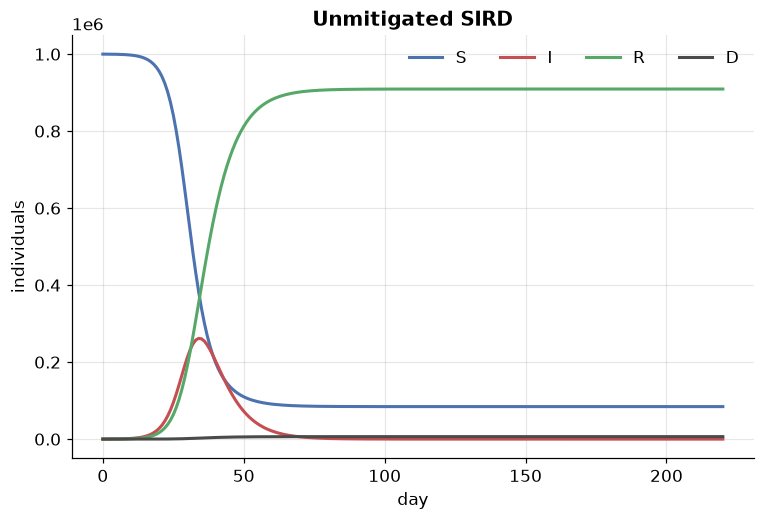

In [4]:
sird = cm.SIRD(cm.SIRDParams(beta, gamma, mu), N)
base = sird.simulate([N - I0, I0, 0, 0], DAYS, DAYS + 1)
print(f"SIRD R0 = {sird.r0():.2f}")
print(f"unmitigated peak infectious = {base['I'].max():,.0f} on day {base['I'].idxmax():.0f}")
print(f"cumulative deaths = {base['D'].iloc[-1]:,.0f}  ({base['D'].iloc[-1]/N:.1%} of population)")

fig, ax = plt.subplots()
plotting.plot_compartments(base, ["S", "I", "R", "D"], ax=ax, title="Unmitigated SIRD")
ax.set_xlabel("day");

## Intervention 1 - lockdown (a time-varying contact rate)

Lockdown is not a new compartment - it is a temporary cut in the contact rate,
so it plugs straight into the model through the `contact_scaling` hook [6]. The
timing of the lockdown is important; a lockdown that starts after the peak does almost nothing.

no lockdown              peak I =  261,603 on day  34   deaths =  6,409
temporary (day 20-80)    peak I =  131,758 on day 103   deaths =  6,028
sustained (day 20+)      peak I =   28,418 on day  26   deaths =  1,993


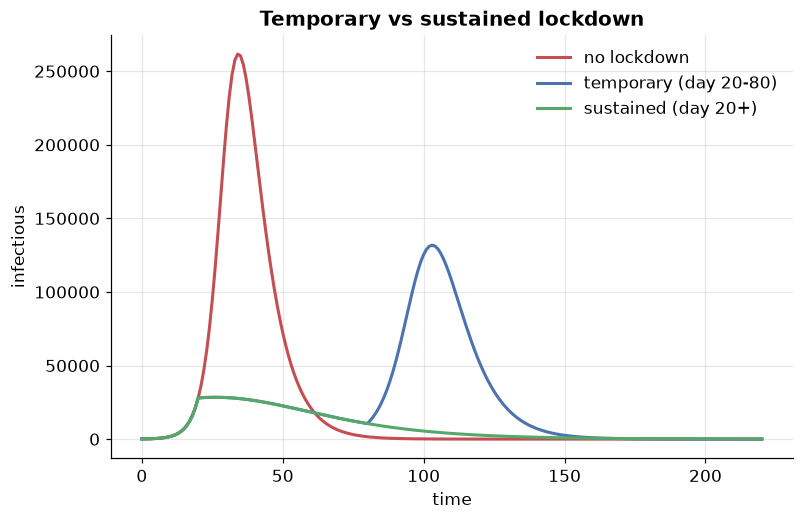

In [ ]:
# A temporary lockdown only delays the peak; a sustained lockdown suppresses the peak.

scenarios = {"no lockdown": base}
for tag, end in [("temporary (day 20-80)", 80), ("sustained (day 20+)", None)]:
    m = cm.SIRD(cm.SIRDParams(beta, gamma, mu), N)
    itv.Lockdown(start=20, end=end, strength=0.6).apply_to(m)
    scenarios[tag] = m.simulate([N - I0, I0, 0, 0], DAYS, DAYS + 1)

curves = {name: (df.index, df["I"]) for name, df in scenarios.items()}
plotting.plot_scenarios(curves, title="Temporary vs sustained lockdown",
                        ylabel="infectious")
for name, df in scenarios.items():
    print(f"{name:24s} peak I = {df['I'].max():8,.0f} on day {df['I'].idxmax():3.0f}   "
          f"deaths = {df['D'].iloc[-1]:6,.0f}")

## Intervention 2 - vaccination (a structural change)

Vaccination *does* need its own compartment, because vaccinated people are a
distinct group who can still be infected but at a reduced rate. That is the
SIRDV model. Here a rolling campaign starts alongside the outbreak.

no vaccine             deaths =   6,409   final susceptible =   84,396
vaccinate 0.5%/day     deaths =   5,586   final susceptible =   38,589
vaccinate 2.0%/day     deaths =   2,592   final susceptible =    4,517


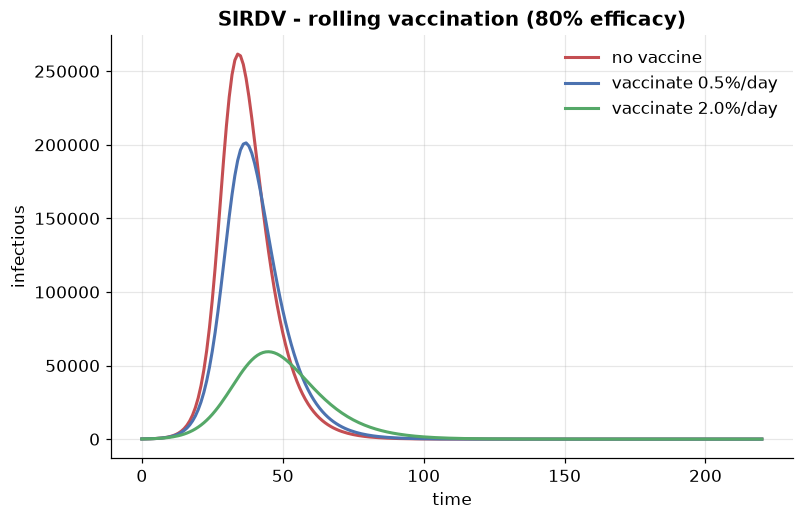

In [6]:
vax_scenarios = {"no vaccine": base}
for nu in [0.005, 0.02]:
    m = cm.SIRDV(cm.SIRDVParams(beta, gamma, mu, nu=nu, efficacy=0.8), N)
    out = m.simulate([N - I0, 0, I0, 0, 0], DAYS, DAYS + 1)
    vax_scenarios[f"vaccinate {nu:.1%}/day"] = out

curves = {name: (df.index, df["I"]) for name, df in vax_scenarios.items()}
plotting.plot_scenarios(curves, title="SIRDV - rolling vaccination (80% efficacy)",
                        ylabel="infectious")
for name, df in vax_scenarios.items():
    print(f"{name:22s} deaths = {df['D'].iloc[-1]:7,.0f}   "
          f"final susceptible = {df['S'].iloc[-1]:8,.0f}")

## Intervention 3 - quarantine (isolating detected cases)

Quarantine needs the extra structure of a latent exposed period and a silent
asymptomatic route, so we switch to the SEAIQR model.
Increasing the isolation rate `q` pulls the reproduction number down directly.

isolation rate q = 0.0   ->  R0 = 2.70   peak infectious =   83,311
isolation rate q = 0.15  ->  R0 = 1.74   peak infectious =   21,822
isolation rate q = 0.4   ->  R0 = 1.27   peak infectious =    2,860


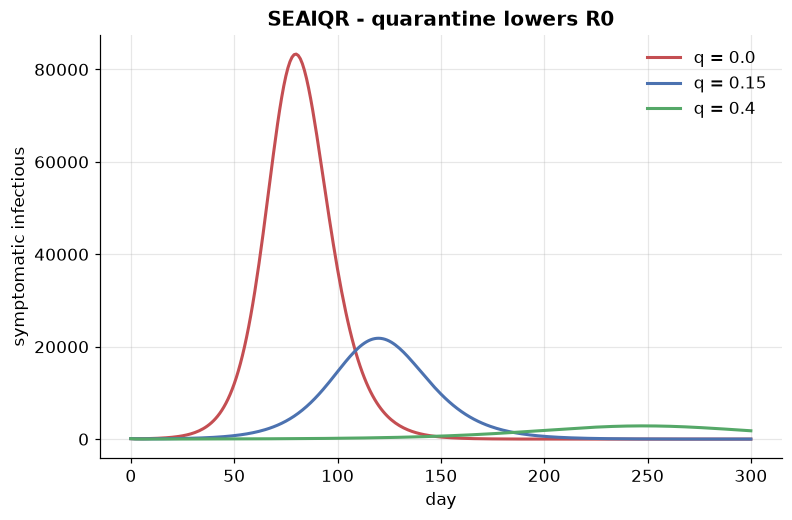

In [7]:
rho, eta = 0.6, 0.5                      # 60% symptomatic; asymptomatics half as infectious
beta_se = R0 * gamma / (eta * (1 - rho) + rho)   # gives R0 = 2.7 at q = 0

q_scenarios = {}
for q in [0.0, 0.15, 0.4]:
    m = cm.SEAIQR(cm.SEAIQRParams(beta_se, sigma, gamma, rho=rho, eta=eta, q=q), N)
    out = m.simulate([N - I0, 0, 0, I0, 0, 0], 300, 301)
    q_scenarios[f"q = {q}"] = out
    print(f"isolation rate q = {q:<4}  ->  R0 = {m.r0():.2f}   "
          f"peak infectious = {out['I'].max():8,.0f}")

curves = {name: (df.index, df["I"]) for name, df in q_scenarios.items()}
plotting.plot_scenarios(curves, title="SEAIQR - quarantine lowers R0",
                        ylabel="symptomatic infectious")
plt.gca().set_xlabel("day");

## Agent-based airborne spread

For an airborne disease the agent rule is proximity: a susceptible can be
infected by any infectious agent within a short radius, not only one sharing its
cell. The three interventions map onto the agents directly - lockdown reduces
movement, vaccination immunises a fraction up front, and quarantine makes
detected cases stop moving.

baseline         peak infectious = 357


lockdown         peak infectious = 236
vaccinate 50%    peak infectious = 46


quarantine 60%   peak infectious = 298


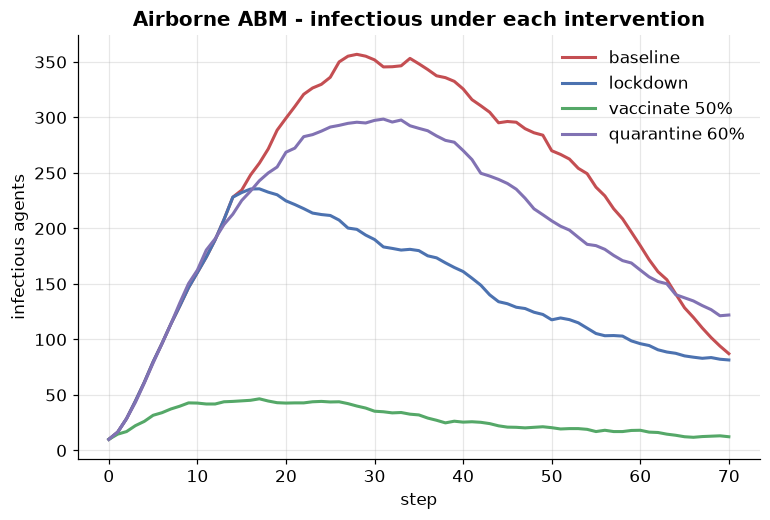

In [8]:
abm_params = ABMParams(infect_prob=0.18, radius=2.0, recovery_prob=0.12, step_prob=0.85)
GRID, NAG, STEPS, RUNS = 80, 2500, 70, 6
common = dict(grid_size=GRID, n_agents=NAG, mechanism="airborne",
              params=abm_params, n_infected=10, base_seed=100)

interventions = {
    "baseline":        None,
    "lockdown":        InterventionSettings(lockdown_start=15, lockdown_step_prob=0.1),
    "vaccinate 50%":   InterventionSettings(vaccinated_fraction=0.5),
    "quarantine 60%":  InterventionSettings(quarantine_fraction=0.6, quarantine_delay=3),
}
abm_curves = {}
for name, iv in interventions.items():
    mean, _ = run_ensemble(RUNS, STEPS, interventions=iv, **common)
    abm_curves[name] = (np.arange(mean.shape[0]), mean[:, State.INFECTIOUS])
    print(f"{name:16s} peak infectious = {mean[:, State.INFECTIOUS].max():.0f}")

plotting.plot_scenarios(abm_curves, title="Airborne ABM - infectious under each intervention",
                        ylabel="infectious agents")
plt.gca().set_xlabel("step");

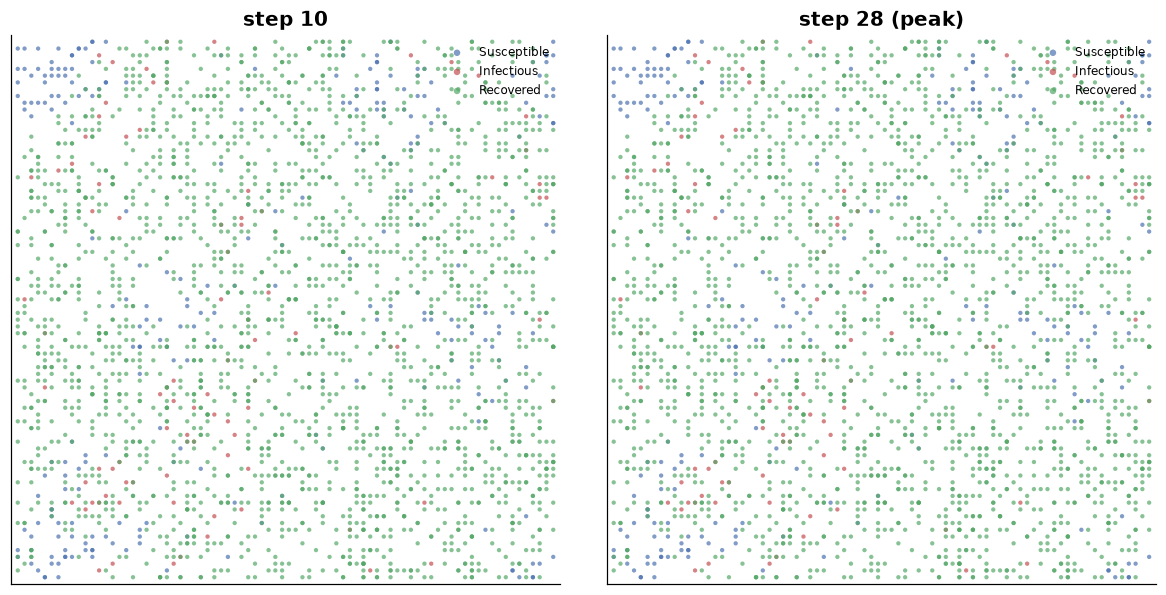

In [ ]:
# A single baseline replicate frozen early and near the peak.

model = RandomWalkModel(GRID, NAG, "airborne", abm_params, n_infected=10, seed=100)
frames = list(model.run(STEPS))
early, mid = frames[10], frames[np.argmax([f.counts[State.INFECTIOUS] for f in frames])]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 5.4))
plotting.plot_grid_snapshot(early.population, GRID, ax=a1, title=f"step {early.t}")
plotting.plot_grid_snapshot(mid.population, GRID, ax=a2, title=f"step {mid.t} (peak)")
plt.tight_layout();

## Validation against the first wave

The unmitigated R0 = 2.7 curve peaks too early and too high for the observed
wave, because distancing was already reducing transmission before any formal
lockdown. So instead of forcing that curve on the data, we fit the effective
reproduction number: scan Re, integrate the SIRD daily incidence, and take the
value (with a single reporting fraction) that best matches the reported cases.

best-fit effective Re = 2.15  (vs unmitigated R0 = 2.70)
fitted reporting fraction = 0.056
model peak day = 43, data peak day = 40 | R^2 = 0.622


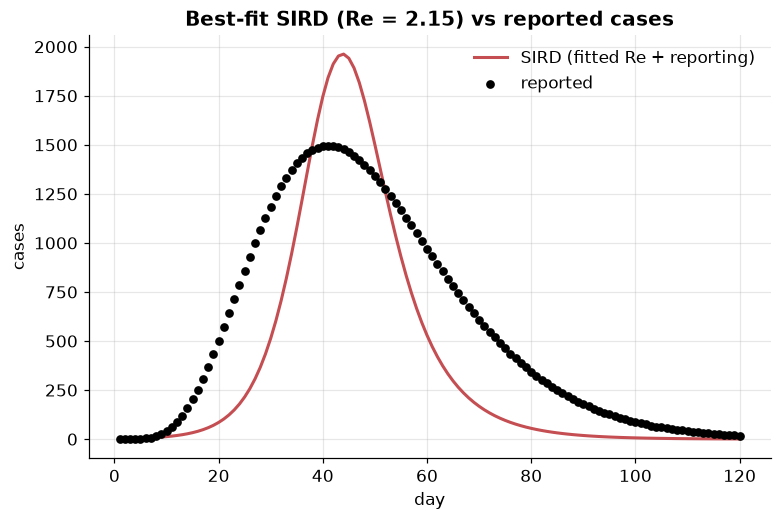

In [10]:
obs = reported["cases"].values

def fit_incidence(Re):
    b = Re * (gamma + mu)
    df = cm.SIRD(cm.SIRDParams(b, gamma, mu), N).simulate([N - I0, I0, 0, 0], DAYS, DAYS + 1)
    inc = (-np.diff(df["S"].values))[: len(obs)]
    scale = np.sum(inc * obs) / np.sum(inc ** 2)          # best reporting fraction
    fitted = inc * scale
    r2 = 1 - np.sum((fitted - obs) ** 2) / np.sum((obs - obs.mean()) ** 2)
    return fitted, scale, r2

candidates = {Re: fit_incidence(Re) for Re in np.round(np.arange(1.4, 2.71, 0.05), 2)}
best_Re = max(candidates, key=lambda k: candidates[k][2])
fitted, reporting_fraction, r2 = candidates[best_Re]
print(f"best-fit effective Re = {best_Re:.2f}  (vs unmitigated R0 = {sird.r0():.2f})")
print(f"fitted reporting fraction = {reporting_fraction:.3f}")
print(f"model peak day = {int(fitted.argmax())}, data peak day = {int(obs.argmax())} | R^2 = {r2:.3f}")

days = np.arange(1, len(obs) + 1)
plotting.plot_model_vs_data(days, fitted, days, obs,
                            title=f"Best-fit SIRD (Re = {best_Re:.2f}) vs reported cases",
                            model_label="SIRD (fitted Re + reporting)", data_label="reported")
plt.gca().set_xlabel("day");

## Summary

In [11]:
rows = {
    "no intervention": metrics.summarise(base["S"], base["I"], base["R"], N,
                                         deaths=base["D"], times=base.index),
}
lock = scenarios["sustained (day 20+)"]
rows["sustained lockdown"] = metrics.summarise(lock["S"], lock["I"], lock["R"], N,
                                               deaths=lock["D"], times=lock.index)
vac = vax_scenarios["vaccinate 2.0%/day"]
rows["vaccination"] = metrics.summarise(vac["S"], vac["I"], vac["R"], N,
                                        deaths=vac["D"], times=vac.index)
metrics.comparison_table(rows).round(2)

,peak_value,peak_time,attack_rate,final_size
no intervention,261603.22,34.0,0.92,915603.51
sustained lockdown,28417.64,26.0,0.28,284667.17
vaccination,59372.92,45.0,1.00,370321.07


## Conclusion 

The three interventions act through different mechanisms. Lockdown is a temporary contact cut - it flattens and delays the peak but the epidemic rebounds when released, unless it buys enough time. Vaccination removes susceptibles permanently and, once fast enough, prevents the wave outright. Quarantine works on the reproduction number itself and is the only one that can push R0 below 1 without confining the whole population - but it needs the SEAIQR structure (latent + asymptomatic) to be modelled honestly, since undetected asymptomatic spread sets a floor on how well isolation can do. The agent-based run reproduces the same ranking spatially.

*Limitations.* 
- Constant R0 (no behavioural feedback or variants)
- Homogeneous mixing in the ODEs